<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_scalar = 1/32  # Hypothetical scalar–tensor coupling


In [2]:
def generate_scalar_field(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X) + np.sin(Y)


In [3]:
def generate_tensor_field(grid_size, phase_shift=0):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X + phase_shift) * np.sin(Y + phase_shift)


In [4]:
def scalar_tensor_coupling(scalar, tensor, beta=1/32):
    grad_scalar_x, grad_scalar_y = np.gradient(scalar)
    grad_tensor_x, grad_tensor_y = np.gradient(tensor)

    theta_scalar = np.arctan2(grad_scalar_y, grad_scalar_x)
    theta_tensor = np.arctan2(grad_tensor_y, grad_tensor_x)
    phase_diff = theta_scalar - theta_tensor

    modulation = -beta * np.sin(phase_diff)
    tensor += modulation
    return scalar, tensor


In [5]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [6]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


Scalar fidelity: 0.9845
Tensor fidelity: 0.9415


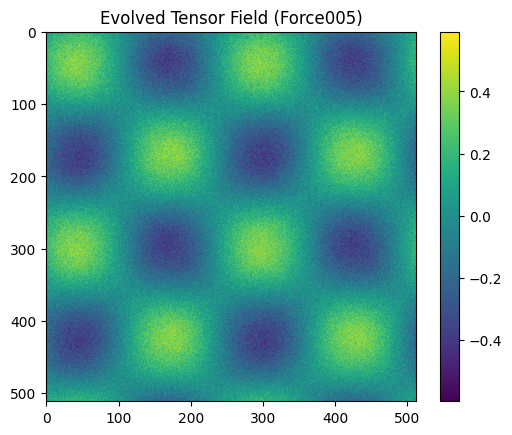

In [7]:
scalar = generate_scalar_field(grid_size)
tensor = generate_tensor_field(grid_size, phase_shift=np.pi/6)
scalar_c, tensor_c = scalar_tensor_coupling(scalar, tensor, beta_scalar)

scalar_e = evolve_field(scalar_c, e_folds)
tensor_e = evolve_field(tensor_c, e_folds)

f_scalar = memory_fidelity(scalar_c, scalar_e)
f_tensor = memory_fidelity(tensor_c, tensor_e)

print(f"Scalar fidelity: {f_scalar:.4f}")
print(f"Tensor fidelity: {f_tensor:.4f}")

plt.imshow(tensor_e, cmap='viridis')
plt.title("Evolved Tensor Field (Force005)")
plt.colorbar()
plt.show()
